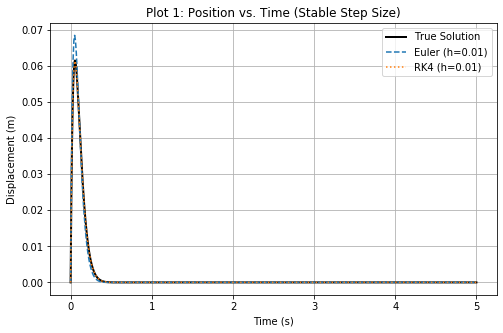

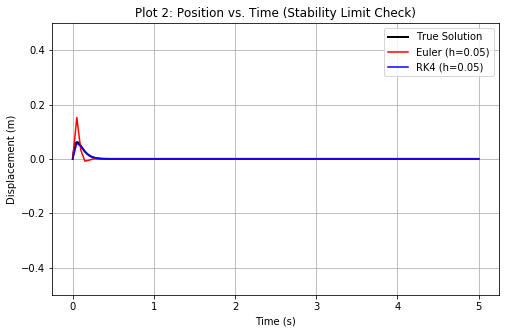

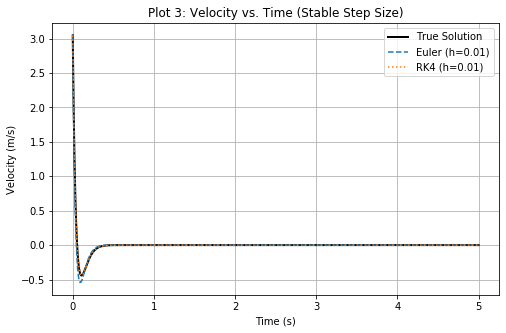

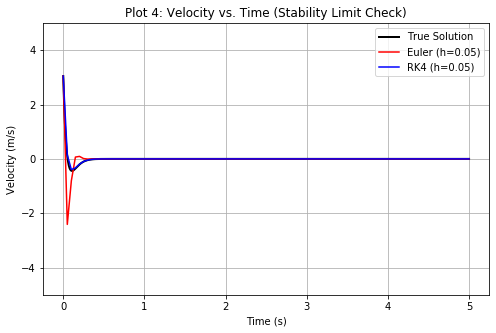

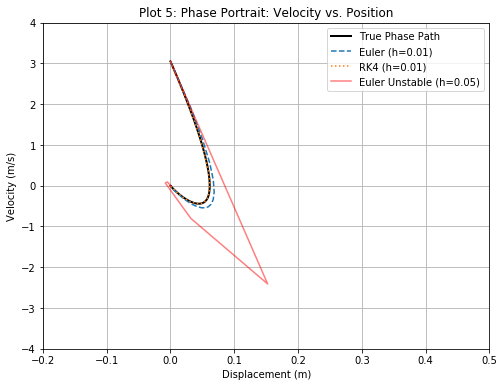

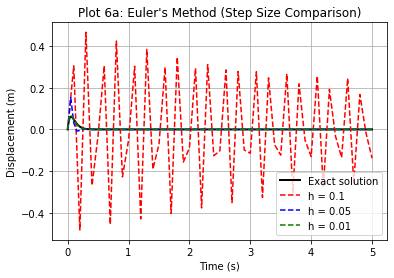

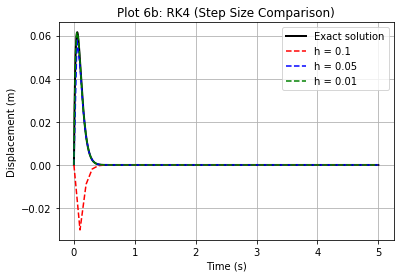

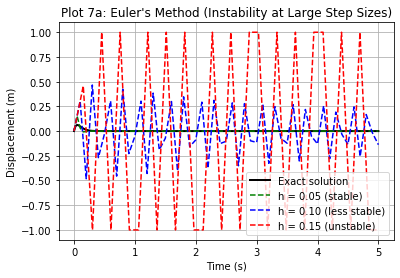

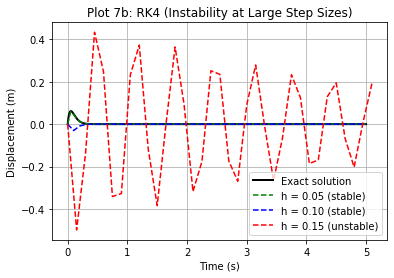

Euler slope: 1.38  (should be close to 1)
RK4   slope: 4.28  (should be close to 4)


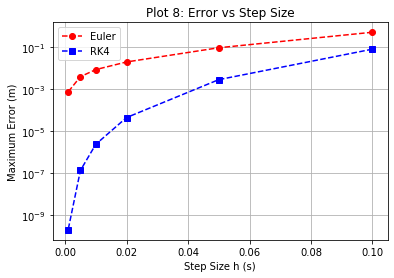

In [2]:
#James Anthony (jma6474)
#Benjamin Price (bdp2294)
#Salma Zobaa (sz22566)


import numpy as np
import matplotlib.pyplot as plt

# ----------- Parameters -----------------

zeta = 0.95   # Damping ratio
f_hz = 3  # Natural frequency (Hz)
omega = f_hz * 2 * np.pi # Convert Hz to rad/s for the ODE

t0 = 0.0     # Initial time in seconds
tf = 5.0    # Final time in seconds

# Initial conditions: y(0) = 0.0, y'(0) = 3.048
# store in array to solve both at once
Y0 = np.array([0.0, 3.048])  # [initial displacement, initial velocity]

# ODE function for the Damped Mechanical System
# Y[0] is displacement, Y[1] is velocity
# store both velocity and displacement in one array
def system_f(t, Y):
    y = Y[0]
    v = Y[1]
    dy_dt = v
    dv_dt = -2 * zeta * omega * v - (omega**2) * y
    return np.array([dy_dt, dv_dt])


# -----------Numerical Methods-----------------

def euler_method(f, y0, t0, tf, h):
    num_steps = int((tf - t0) / h)
    t_values = np.linspace(t0, tf, num_steps + 1)
    
    # hold displacement and velocity
    y_values = np.zeros((num_steps + 1, len(y0)))
    
    y_values[0] = y0 
    
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])
        
    return t_values, y_values

def runge_kutta_4(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    
    # hold displacement and velocity
    y_values = np.zeros((len(t_values), len(y0)))
    
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]            
        
        k1 = h * f(t, y)
        k2 = h * f(t + h / 2, y + k1 / 2)
        k3 = h * f(t + h / 2, y + k2 / 2)
        k4 = h * f(t + h, y + k3)
        
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        
    return t_values, y_values


# ----------- Exact Solution -----------------

def exact(t):
    wd = omega * np.sqrt(1 - zeta**2)
    A  = Y0[0]
    B  = (Y0[1] + zeta * omega * Y0[0]) / wd
    return np.exp(-zeta * omega * t) * (A * np.cos(wd * t) + B * np.sin(wd * t))


# ----------- Testing and PLotting -----------------------------

# Get a baseline using a tiny step size
t_perf, Y_perf = runge_kutta_4(system_f, Y0, t0, tf, 0.0001)
displacement_perf = Y_perf[:, 0]
velocity_perf = Y_perf[:, 1]

# Run tests for a stable step size (h = 0.01)
h_stable = 0.01

t_euler_s, Y_euler_s = euler_method(system_f, Y0, t0, tf, h_stable)
displacement_euler_s = Y_euler_s[:, 0]
velocity_euler_s = Y_euler_s[:, 1]

t_rk4_s, Y_rk4_s = runge_kutta_4(system_f, Y0, t0, tf, h_stable)
displacement_rk4_s = Y_rk4_s[:, 0]
velocity_rk4_s = Y_rk4_s[:, 1]

# Run tests for an unstable step size (h = 0.05) to break Euler
h_unstable = 0.05

t_euler_u, Y_euler_u = euler_method(system_f, Y0, t0, tf, h_unstable)
displacement_euler_u = Y_euler_u[:, 0]
velocity_euler_u = Y_euler_u[:, 1]

t_rk4_u, Y_rk4_u = runge_kutta_4(system_f, Y0, t0, tf, h_unstable)
displacement_rk4_u = Y_rk4_u[:, 0]
velocity_rk4_u = Y_rk4_u[:, 1]

# Plot 1: Position vs Time (Stable) 
plt.figure(figsize=(8, 5))
plt.plot(t_perf, displacement_perf, label='True Solution', color='black', linewidth=2)
plt.plot(t_euler_s, displacement_euler_s, label='Euler (h=0.01)', linestyle='--')
plt.plot(t_rk4_s, displacement_rk4_s, label='RK4 (h=0.01)', linestyle=':')
plt.title("Plot 1: Position vs. Time (Stable Step Size)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Position vs Time (Unstable)
plt.figure(figsize=(8, 5))
plt.plot(t_perf, displacement_perf, label='True Solution', color='black', linewidth=2)
plt.plot(t_euler_u, displacement_euler_u, label='Euler (h=0.05)', color='red')
plt.plot(t_rk4_u, displacement_rk4_u, label='RK4 (h=0.05)', color='blue')
plt.title("Plot 2: Position vs. Time (Stability Limit Check)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.ylim(-0.5, 0.5) 
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Velocity vs Time (Stable)
plt.figure(figsize=(8, 5))
plt.plot(t_perf, velocity_perf, label='True Solution', color='black', linewidth=2)
plt.plot(t_euler_s, velocity_euler_s, label='Euler (h=0.01)', linestyle='--')
plt.plot(t_rk4_s, velocity_rk4_s, label='RK4 (h=0.01)', linestyle=':')
plt.title("Plot 3: Velocity vs. Time (Stable Step Size)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()


# Plot 4: Velocity vs Time (Unstable) 
plt.figure(figsize=(8, 5))
plt.plot(t_perf, velocity_perf, label='True Solution', color='black', linewidth=2)
plt.plot(t_euler_u, velocity_euler_u, label='Euler (h=0.05)', color='red')
plt.plot(t_rk4_u, velocity_rk4_u, label='RK4 (h=0.05)', color='blue')
plt.title("Plot 4: Velocity vs. Time (Stability Limit Check)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.ylim(-5, 5)
plt.legend()
plt.grid(True)
plt.show()

# Plot 5: Phase Portrait
plt.figure(figsize=(8, 6))
plt.plot(displacement_perf, velocity_perf, label='True Phase Path', color='black', linewidth=2)
plt.plot(displacement_euler_s, velocity_euler_s, label='Euler (h=0.01)', linestyle='--')
plt.plot(displacement_rk4_s, velocity_rk4_s, label='RK4 (h=0.01)', linestyle=':')
plt.plot(displacement_euler_u, velocity_euler_u, label='Euler Unstable (h=0.05)', color='red', alpha=0.5)
plt.title("Plot 5: Phase Portrait: Velocity vs. Position")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.xlim(-0.2, 0.5)
plt.ylim(-4, 4)
plt.legend()
plt.grid(True)
plt.show()


# Plot 6a: Euler step size comparison

t_exact = np.linspace(t0, tf, 1000)

plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-', linewidth=2, label='Exact solution')
t1, y1 = euler_method(system_f, Y0, t0, tf, 0.1)
plt.plot(t1, y1[:, 0], 'r--', linewidth=1.5, label='h = 0.1')
t2, y2 = euler_method(system_f, Y0, t0, tf, 0.05)
plt.plot(t2, y2[:, 0], 'b--', linewidth=1.5, label='h = 0.05')
t3, y3 = euler_method(system_f, Y0, t0, tf, 0.01)
plt.plot(t3, y3[:, 0], 'g--', linewidth=1.5, label='h = 0.01')
plt.title("Plot 6a: Euler's Method (Step Size Comparison)")
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 6b: RK4 step size comparison

plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-', linewidth=2, label='Exact solution')
t1, y1 = runge_kutta_4(system_f, Y0, t0, tf, 0.1)
plt.plot(t1, y1[:, 0], 'r--', linewidth=1.5, label='h = 0.1')
t2, y2 = runge_kutta_4(system_f, Y0, t0, tf, 0.05)
plt.plot(t2, y2[:, 0], 'b--', linewidth=1.5, label='h = 0.05')
t3, y3 = runge_kutta_4(system_f, Y0, t0, tf, 0.01)
plt.plot(t3, y3[:, 0], 'g--', linewidth=1.5, label='h = 0.01')
plt.title('Plot 6b: RK4 (Step Size Comparison)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 7a: Euler instability

plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-', linewidth=2, label='Exact solution')
t1, y1 = euler_method(system_f, Y0, t0, tf, 0.05)
plt.plot(t1, y1[:, 0], 'g--', linewidth=1.5, label='h = 0.05 (stable)')
t2, y2 = euler_method(system_f, Y0, t0, tf, 0.10)
plt.plot(t2, y2[:, 0], 'b--', linewidth=1.5, label='h = 0.10 (less stable)')
t3, y3 = euler_method(system_f, Y0, t0, tf, 0.15)
y3_clipped = np.clip(y3[:, 0], -1, 1)
plt.plot(t3, y3_clipped, 'r--', linewidth=1.5, label='h = 0.15 (unstable)')
plt.title("Plot 7a: Euler's Method (Instability at Large Step Sizes)")
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 7b: RK4 instability

plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-', linewidth=2, label='Exact solution')
t1, y1 = runge_kutta_4(system_f, Y0, t0, tf, 0.05)
plt.plot(t1, y1[:, 0], 'g--', linewidth=1.5, label='h = 0.05 (stable)')
t2, y2 = runge_kutta_4(system_f, Y0, t0, tf, 0.10)
plt.plot(t2, y2[:, 0], 'b--', linewidth=1.5, label='h = 0.10 (stable)')
t3, y3 = runge_kutta_4(system_f, Y0, t0, tf, 0.15)
y3_clipped = np.clip(y3[:, 0], -1, 1)
plt.plot(t3, y3_clipped, 'r--', linewidth=1.5, label='h = 0.15 (unstable)')
plt.title('Plot 7b: RK4 (Instability at Large Step Sizes)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 8: Error vs step size

h_list = [0.1, 0.05, 0.02, 0.01, 0.005, 0.001]
euler_errors = []
rk4_errors   = []

for h in h_list:
    t_e, y_e = euler_method(system_f, Y0, t0, tf, h)
    t_r, y_r = runge_kutta_4(system_f, Y0, t0, tf, h)
    euler_errors.append(np.max(np.abs(y_e[:, 0] - exact(t_e))))
    rk4_errors.append(np.max(np.abs(y_r[:, 0] - exact(t_r))))

h_arr = np.array(h_list)
slope_euler = np.polyfit(np.log(h_arr), np.log(euler_errors), 1)[0]
slope_rk4   = np.polyfit(np.log(h_arr), np.log(rk4_errors),   1)[0]

print("Euler slope:", round(slope_euler, 2), " (should be close to 1)")
print("RK4   slope:", round(slope_rk4,   2), " (should be close to 4)")

plt.figure()
plt.semilogy(h_arr, euler_errors, 'ro--', label="Euler")
plt.semilogy(h_arr, rk4_errors,  'bs--',label="RK4")
plt.title('Plot 8: Error vs Step Size')
plt.xlabel('Step Size h (s)')
plt.ylabel('Maximum Error (m)')
plt.legend()
plt.grid(True)
plt.show()

---Section 1: Introduction---

Model Selection: Damped Mechanical System
•	ODE: y’’+2𝛇⍵y’+(⍵^2)y
•	Application:Airplane landing gear shock absorbers
In this analysis we will be simulating the behavior of the shock struts in the landing gears of a Boeing 747-400 at landing. These shock absorbers are crucial to the comfort and safety of the passengers and crew, absorbing the massive landing forces and preventing the shock from damaging the frame of the aircraft and injuring its passengers. The struts consist of a hydraulic fluid that is forced through an orifice by a piston, compressing a gas and thus absorbing the impact of the landing. The return of the hydraulic fluid back to its original chamber is limited by the orifice size, thus damping the recoil of the shock absorber. The governing ODE for this system is the damped mechanical system equation: y’’+2𝛇⍵y’+(⍵^2)y=0, where the unknown function y(t) is the displacement of the landing gear from equilibrium, y’ is the first derivative of y(t), y’’ is the second derivative of y(t), 𝛇 is a dimensionless damping ratio, and ⍵ is the natural frequency of the system. The damping ratio indicates how quickly the energy in the system will be dissipated, while the natural frequency indicates the oscillation frequency of this system in its undamped state.  Converting this 2nd order ODE to a system of 1st order ODEs of the form Ax=x’, x=(x1,x2) gives A=[[0,1],[-⍵^2, -2𝛇⍵]], with x1=y(t), x2=y’(t).



---Section 2: Parameters---

Simplifying assumptions:
In the moments just before touchdown the aircraft descends with a constant speed, the landing gears have a landing load factor (N) of 1.2 (the most commonly used value) [5], the damping force is linear with velocity, 75% of the energy of landing will be dissipated on the downstroke (based on the decay of velocity according to e^-bt/m, where b is the damping coefficient or the damping force per unit velocity), and the multiple landing gears of the aircraft will be treated as one dampened mechanical oscillator.

Initial conditions:
y(0)=0  (System starts at equilibrium)
y’(0)=3.048 m/s (Vertical speed of aircraft at touchdown)



| Variable                  | Value (Units)        | Justification |
|---------------------------|---------------------|----------------|
| Total Dissipated Energy   | 1,248,328 (Joules)  | 1/2mv^2 |
| Vertical Speed at Impact  | 3.048 m/s           | Federal Regulations [3] |
| Aircraft Landing Mass     | 268,738.86 kg       | Boeing 747-400 Specifications [2] |
| Damping Ratio             | 0.95                | By inference, landing gear should be near critically damped [4] (Figure 7) 
| Natural frequency         | 3 Hz                | sqrt(k/m) |
| Effective Spring Constant | 2560782 N/m         | 2*(Potential energy conserved after downstroke)/Stroke^2 |
| Landing gear stroke       | 0.4937 m            | .8SNW = WV^2 / 2g [5] |


References:  
[1] W. Flugge, Landing Gear Impact, NACA, TN2743, 1952
[2] Guest, and www.airplanesandpilots.wordpress.com. “Home.” Commercial Aircraft. Pictures, Specifications, Reviews., 26 July 2019, www.airlines-inform.com/commercial-aircraft/boeing -747-400.html. 
[3]“Request Access.” Federal Register :: Request Access, www.ecfr.gov/current/title-14/ chapter-I/subchapter-C/part-25/subpart-C/subject-group-ECFRabacbe77efb6607. Accessed 21 Apr. 2026. 
[4]International Journal of Recent Technology and Engineering (IJRTE), www.ijrte.org/wp-content/uploads/papers/v8i5/D9247118419.pdf. Accessed 21 Apr. 2026. 
[5] “NASA Technical Reports Server (NTRS).” NASA, NASA, https://ntrs.nasa.g ov/api/citations/19970031272/downloads/19970031272.pdf. Accessed 21 Apr. 2026. 



---Section 3: Numerical Methods Implementation---

To numerically approximate the second order differential equation representing the damped mechanical system in a Boeing 747, the equation was broken down into two first order differential equations. One equation represents displacement and the other represents velocity. These first order equations were combined to create a state vector Y = [y, v] which is managed by a python numpy array. The function system_f(t, Y) calculates and returns the derivates of both equations simultaneously.

Two numerical approximation methods were implemented: Euler's Forward Method and Fourth-Order Runge-Kutta (RK4). Euler's method is a first-order explicit way of calculation, where it calculates the slopes for both displacement and velocity at the current point and uses them to project the state forward by step size $h$. Because it only uses the initial slope of the interval, it is prone to accumulating error quickly. As for RK4, instead of relying on a single slope, RK4 calculates four distinct slopes ($k_1, k_2, k_3, k_4$) across the time interval $h$. It combines these using a weighted average to highly accurately predict the next state. Both of these numerical solvers were vectorized to efficiently update both velocity and displacement in a single iteration.



---Section 4: Solutions & Comparison---

Position and Velocity vs. Time Plots: At a small step size (h = 0.01), both methods match up with the true solutions well, with the RK4 being much more accurate while Euler slightly diverges. At a larger step size (h = 0.05), RK4 remains stable and holds well, accurately tracking the rapid damping. On the other hand, Euler's method completely fails in accuracy and oscillates violently. The preceding descriptions for both methods applies for both the Position vs. Time and Velocity vs. Time plots, comparing both methods respectively.

Phase Portraits (Velocity vs. Position): Since the system is heavily damped, the true path quickly arcs inward to the origin (0,0) as it loses energy. RK4 maps this trajectory perfectly for both step sizes. Euler at h = 0.1 roughly follows the path, but at h = 0.5, it spirals outward uncontrollably. The Euler method incorrectly suggests that the system gains energy when in reality the system loses energy instead.



---Section 5: Stability Analysis---

Plot 6a and 6b show the displacement of the Boeing 747-400 landing gear over time for both Eulers forward method and RK4 at three different step sizes (h = 0.1, 0.05, and 0.01), compared against the exact analytical solution. For both methods, h = 0.1 was the most different from the exact solution, h = 0.01 was nearly perfect. This confirms that smaller step sizes produce more accurate results, as the numerical method has to make smaller and more frequent approximations. RK4 tracked the exact solution more closely than Euler's method at the same step size, meaning RK4 can achieve good accuracy without needing as small a step size as Euler

Plot 7a and 7b demonstrate what happens when the step size becomes too large. At h = 0.15, both methods produced solutions that diverged wildly from the exact solution rather than decaying to zero. This is physically impossible for a landing gear shock absorber because in reality the damper dissipates energy and the displacement must decrease over time until the gear settles. When the numerical solution grows instead of decays, it means the method has become unstable and is producing completely bad results. Euler's method reached this instability at a smaller step size than RK4, meaning RK4 has a larger stable range and is the safer choice for this simulation. For a damped system like a shock absorber, numerical instability causes the computed energy to increase over time rather than decrease, which is physically impossible and would lead to dangerously wrong conclusions in an engineering design context.

Plot 8 plots the maximum error of each method against step size. As step size decreases, both methods become more accurate, but at very different rates. The computed slopes confirm Euler's method has a slope close to 1, meaning its error shrinks linearly as step size shrinks. RK4 has a slope close to 4, meaning its error shrinks much faster. So if you cut the step size in half, Euler's error is reduced by half, but RK4's error is reduced by a factor of 16. This makes RK4 more efficient for this problem.



---Section 6: Conclusions---

Overall, RK4 was a lot better then Eulers forward method for simulating the Boeing 747-400 landing gear shock absorber. RK4 produced more accurate results at larger step sizes, maintained stability over a wider range of step sizes, and its error converged at a fourth-order rate compared to Euler's first-order rate. While Euler's method is simpler to implement and requires fewer calculations per step, the accuracy tradeoff makes it worse for a system as safety as aircraft landing gear, where an inaccurate or unstable simulation could lead to dangerous design decisions. RK4 was the better balance between computational cost and accuracy for this problem. The key lesson from this analysis is that choosing the right numerical method and an appropriate step size are not just mathematical decisions, they have direct physical consequences.


